# MLP Dropout & Early Stopping

## الترتيب / Flow
1. استيراد المكتبات - Import libraries
2. قراءة البيانات - Load dataset
3. تجهيز `X` و `y` - Prepare features and target
4. تقسيم البيانات - Train/Test split
5. Feature scaling - Standardization
6. نموذج بدون Dropout - Plain MLP
7. نموذج مع Dropout + EarlyStopping - Regularized MLP
8. مقارنة منحنيات train/val loss - Learning curves
9. مقارنة الدقة على test set

In [1]:
# Step 1) استيراد المكتبات / Import libraries
# pip install tensorflow -q  # uncomment in Colab if needed
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Step 2) قراءة البيانات / Load dataset
import os
import urllib.request

filename = 'Social_Network_Ads.csv'
if not os.path.exists(filename):
    url = 'https://raw.githubusercontent.com/iksasa15/AI-ML/main/code/15-%20Deep%20Learning/3-%20MLP%20Dropout%20Regularization/Social_Network_Ads.csv'
    urllib.request.urlretrieve(url, filename)

dataset = pd.read_csv(filename)
dataset.head()


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
# Step 3) تجهيز X و y / Prepare features and target
X = dataset.iloc[:, [2, 3]].values
y = dataset.iloc[:, 4].values

In [4]:
# Step 4) تقسيم البيانات / Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [5]:
# Step 5) Feature scaling / Standardization
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [6]:
# Step 6) نموذج بدون Dropout / Plain MLP (may overfit)
model_plain = Sequential([
    Dense(units=128, activation='relu', input_shape=(2,)),
    Dense(units=64, activation='relu'),
    Dense(units=32, activation='relu'),
    Dense(units=1, activation='sigmoid')
])
model_plain.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_plain = model_plain.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_split=0.2,
    verbose=0
)
plain_loss, plain_acc = model_plain.evaluate(X_test, y_test, verbose=0)
print(f'Plain MLP test accuracy: {plain_acc:.2%}')

C:\Users\A7MED\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Plain MLP test accuracy: 95.00%


In [7]:
# Step 7) نموذج مع Dropout + EarlyStopping / Regularized MLP
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model_dropout = Sequential([
    Dense(units=128, activation='relu', input_shape=(2,)),
    Dropout(0.3),
    Dense(units=64, activation='relu'),
    Dropout(0.3),
    Dense(units=32, activation='relu'),
    Dense(units=1, activation='sigmoid')
])
model_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_dropout = model_dropout.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)
dropout_loss, dropout_acc = model_dropout.evaluate(X_test, y_test, verbose=0)
print(f'Dropout MLP test accuracy: {dropout_acc:.2%}')

Dropout MLP test accuracy: 95.00%


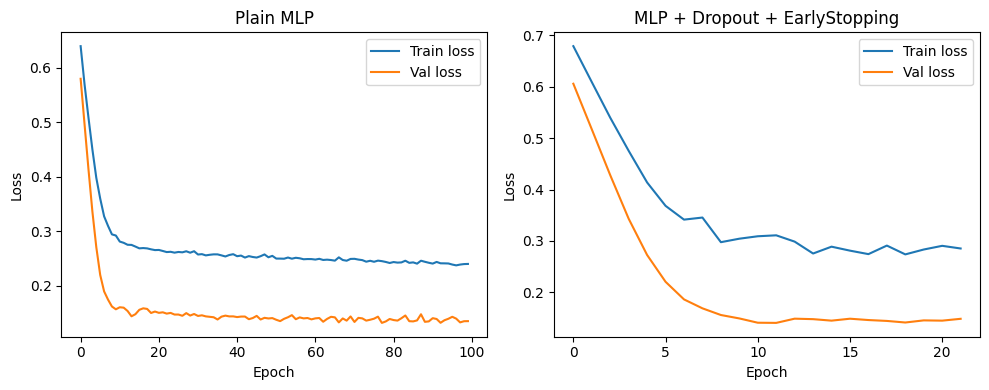

In [8]:
# Step 8) مقارنة منحنيات loss / Compare train vs val loss
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_plain.history['loss'], label='Train loss')
plt.plot(history_plain.history['val_loss'], label='Val loss')
plt.title('Plain MLP')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dropout.history['loss'], label='Train loss')
plt.plot(history_dropout.history['val_loss'], label='Val loss')
plt.title('MLP + Dropout + EarlyStopping')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
# Step 9) مقارنة الدقة / Compare test accuracy
print('--- Regularization Comparison ---')
print(f'Plain MLP:    {plain_acc:.2%}')
print(f'Dropout MLP:  {dropout_acc:.2%}')
print('Watch val loss: if train drops but val rises, the plain model is overfitting.')

--- Regularization Comparison ---
Plain MLP:    95.00%
Dropout MLP:  95.00%
Watch val loss: if train drops but val rises, the plain model is overfitting.
